In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [13]:
df = pd.read_csv('data/stud.csv')

In [14]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [17]:
x = df.drop(columns=['math_score'])
y = df['math_score']

In [20]:
num_features = x.select_dtypes(exclude='object').columns
cat_features = x.select_dtypes(include='object').columns

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_transform = StandardScaler()
cat_transform = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("One Hot Encoding", cat_transform, cat_features),
        ("Standardize", num_transform, num_features)
    ],remainder="passthrough"
)

In [25]:
x = preprocessor.fit_transform(x)

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=20)

In [32]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train) 

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3828
- Mean Absolute Error: 4.2779
- R2 Score: 0.8782
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3620
- Mean Absolute Error: 4.2817
- R2 Score: 0.8631


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5252
- Mean Absolute Error: 5.1203
- R2 Score: 0.8209
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.3830
- Mean Absolute Error: 5.0908
- R2 Score: 0.8060


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3173
- Mean Absolute Error: 4.2179
- R2 Score: 0.8811
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3808
- Mean Absolute Error: 4.3231
- R2 Score: 0.8621


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.6515
- Mean Absolute Error: 4.4777
- R2 Score: 0.8657
-----------------------

e:\Code\DS_ML_DL_NLP\Projects\MLPROJECT\venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\Code\DS_ML_DL_NLP\Projects\MLPROJECT\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "e:\Code\DS_ML_DL_NLP\Projects\MLPROJECT\venv\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "e:\Code\DS_ML_DL_NLP\Projects\MLPROJECT\venv\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "e:\Code\DS_ML_DL_NLP\Projects\MLPROJECT\venv\lib\subprocess.py", line 1327, in _execute_child
    hp, h

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 2.2837
- Mean Absolute Error: 1.7992
- R2 Score: 0.9781
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.3178
- Mean Absolute Error: 5.0633
- R2 Score: 0.8099


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 0.8186
- Mean Absolute Error: 0.5134
- R2 Score: 0.9972
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.9107
- Mean Absolute Error: 5.4581
- R2 Score: 0.7726


CatBoosting Regressor
Model performance for Training set
- Root Mean Squared Error: 2.8529
- Mean Absolute Error: 2.2183
- R2 Score: 0.9658
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.0083
- Mean Absolute Error: 4.7669
- R2 Score: 0.8281


AdaBoost Regressor
Model performance for Training set
- Root Mean Squared Error: 5.6833
- Mean Absolute Error: 4.6577
- R2 Score: 0.86

In [34]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.863103
2,Ridge,0.862145
7,CatBoosting Regressor,0.828113
5,Random Forest Regressor,0.809948
1,Lasso,0.806006
8,AdaBoost Regressor,0.785221
6,XGBRegressor,0.772607
3,K-Neighbors Regressor,0.761903
4,Decision Tree,0.677588


In [37]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 86.31


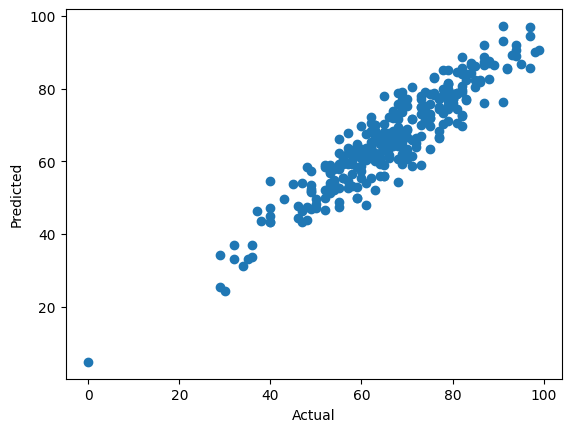

In [38]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

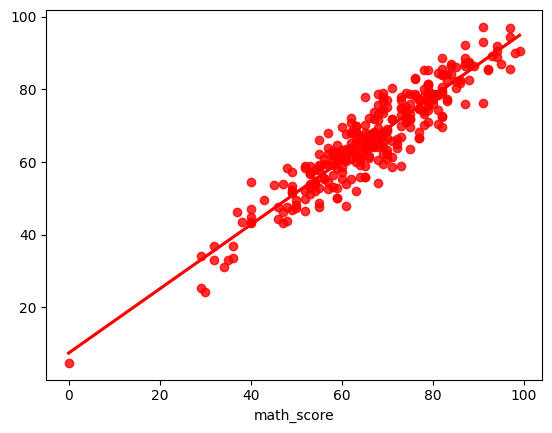

In [39]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [40]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
890,86,82.500,3.500
694,49,51.500,-2.500
798,69,68.375,0.625
147,73,69.875,3.125
858,52,52.000,0.000
...,...,...,...
257,78,80.000,-2.000
591,71,61.500,9.500
377,85,80.500,4.500
938,85,86.250,-1.250
